# Station-MAE — Training Log Viewer

Load `logs.csv` from one or more checkpoint directories and inspect:

- Train vs validation loss curve
- Validation RMSE curve
- Time per epoch
- Best epoch + early-stopping marker
- Per-variable RMSE (if available in a multi-run comparison)

Set `LOG_DIRS` below to point at your checkpoint folder(s).

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Config ─────────────────────────────────────────────────────────────────
# Add as many directories as you like — each gets its own colour in the
# comparison plots.  Labels default to the folder name.
LOG_DIRS = [
    "./checkpoints_mini",     # quick sanity-check run from explore_pipeline
    # "./checkpoints/run1",   # add more runs to compare
]

# Palette — extend if you add more runs
PALETTE = ["steelblue", "tomato", "seagreen", "darkorchid", "darkorange"]

print("Config loaded.")

Config loaded.


In [3]:
# ── Load all logs ──────────────────────────────────────────────────────────
runs = []
for d in LOG_DIRS:
    csv_path = os.path.join(d, "logs.csv")
    if not os.path.exists(csv_path):
        print(f"  [skip] {csv_path} not found")
        continue
    df = pd.read_csv(csv_path)
    label = os.path.basename(os.path.normpath(d))
    runs.append({"label": label, "dir": d, "df": df})
    print(f"  Loaded: {csv_path}  ({len(df)} epochs, columns: {list(df.columns)})")

if not runs:
    raise FileNotFoundError("No logs.csv found — check LOG_DIRS above.")

  Loaded: ./checkpoints_mini/logs.csv  (8 epochs, columns: ['epoch', 'train_loss', 'val_loss', 'val_rmse', 'epoch_secs'])


## 1 — Summary table

In [4]:
rows = []
for r in runs:
    df = r["df"]
    best_idx   = df["val_loss"].idxmin()
    best_epoch = int(df.loc[best_idx, "epoch"])
    best_val   = float(df.loc[best_idx, "val_loss"])
    best_rmse  = float(df.loc[best_idx, "val_rmse"]) if "val_rmse" in df.columns else float("nan")
    final_train = float(df["train_loss"].iloc[-1])
    total_time_h = df["epoch_secs"].sum() / 3600 if "epoch_secs" in df.columns else float("nan")
    rows.append({
        "Run":           r["label"],
        "Epochs run":    len(df),
        "Best epoch":    best_epoch,
        "Best val_loss": round(best_val,  5),
        "Best val_rmse": round(best_rmse, 5),
        "Final train":   round(final_train, 5),
        "Total time (h)": round(total_time_h, 2),
    })

summary = pd.DataFrame(rows).set_index("Run")
display(summary)

,Epochs run,Best epoch,Best val_loss,Best val_rmse,Final train,Total time (h)
Run,,,,,,
checkpoints_mini,8,5,0.64323,0.80209,0.51292,0.01


## 2 — Loss curves

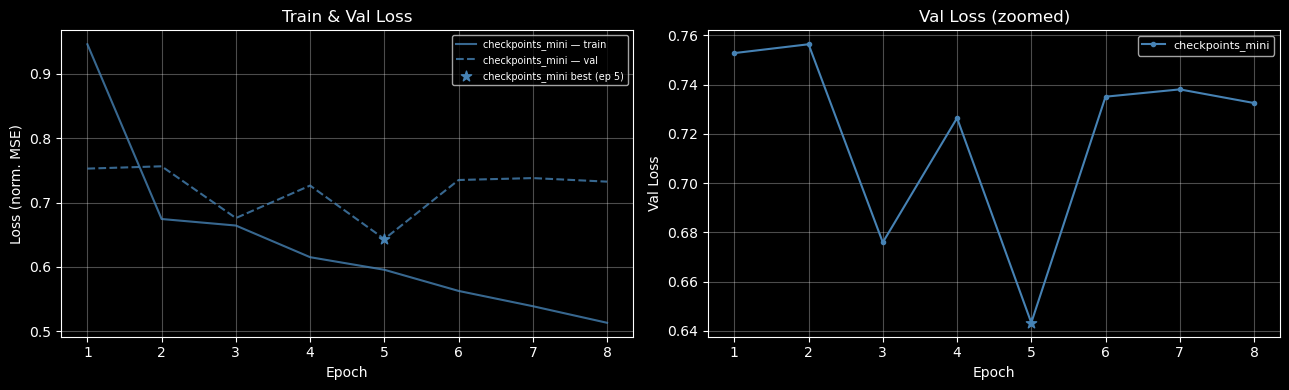

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, r in enumerate(runs):
    df    = r["df"]
    color = PALETTE[i % len(PALETTE)]
    label = r["label"]
    ep    = df["epoch"]

    # ── Left: train + val loss ───────────────────────────────────────────
    ax = axes[0]
    ax.plot(ep, df["train_loss"], "-",  color=color, alpha=0.8,
            label=f"{label} — train")
    ax.plot(ep, df["val_loss"],   "--", color=color, alpha=0.8,
            label=f"{label} — val")

    # Mark best epoch
    best_idx = df["val_loss"].idxmin()
    best_ep  = df.loc[best_idx, "epoch"]
    best_vl  = df.loc[best_idx, "val_loss"]
    ax.scatter([best_ep], [best_vl], color=color, s=60, zorder=5,
               marker="*", label=f"{label} best (ep {int(best_ep)})")

    # ── Right: val loss only (cleaner) ───────────────────────────────────
    ax = axes[1]
    ax.plot(ep, df["val_loss"], "-o", color=color, ms=3, label=label)
    ax.scatter([best_ep], [best_vl], color=color, s=60, zorder=5, marker="*")

axes[0].set_title("Train & Val Loss");  axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (norm. MSE)"); axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].set_title("Val Loss (zoomed)"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Loss");         axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3 — Validation RMSE

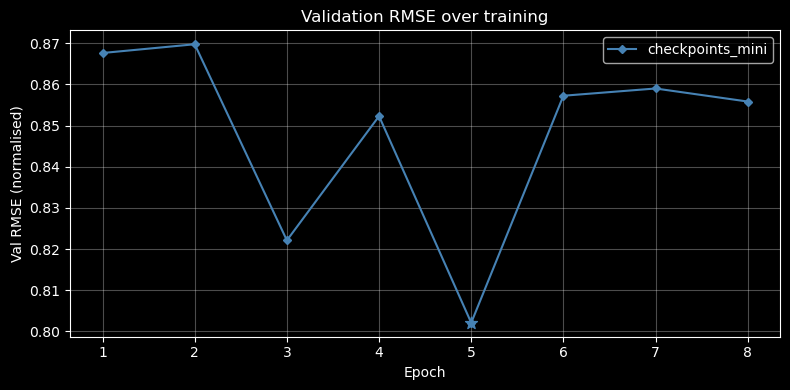

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, r in enumerate(runs):
    df    = r["df"]
    color = PALETTE[i % len(PALETTE)]
    if "val_rmse" not in df.columns:
        print(f"  {r['label']}: no val_rmse column, skipping")
        continue
    ax.plot(df["epoch"], df["val_rmse"], "-D", color=color,
            ms=4, label=r["label"])
    best_idx = df["val_rmse"].idxmin()
    ax.scatter([df.loc[best_idx, "epoch"]], [df.loc[best_idx, "val_rmse"]],
               color=color, s=80, marker="*", zorder=5)

ax.set_xlabel("Epoch"); ax.set_ylabel("Val RMSE (normalised)")
ax.set_title("Validation RMSE over training"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4 — Epoch time

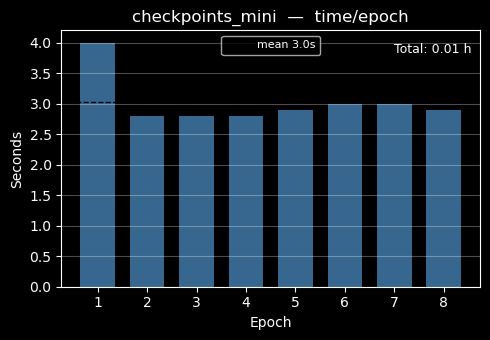

In [7]:
n_runs = len(runs)
fig, axes = plt.subplots(1, n_runs, figsize=(5 * n_runs, 3.5), squeeze=False)

for i, r in enumerate(runs):
    df    = r["df"]
    color = PALETTE[i % len(PALETTE)]
    ax    = axes[0][i]

    if "epoch_secs" not in df.columns:
        ax.set_title(f"{r['label']}\n(no epoch_secs column)")
        continue

    ax.bar(df["epoch"], df["epoch_secs"], color=color, width=0.7, alpha=0.8)
    mean_s = df["epoch_secs"].mean()
    ax.axhline(mean_s, color="k", lw=1, ls="--", label=f"mean {mean_s:.1f}s")
    ax.set_title(f"{r['label']}  —  time/epoch")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Seconds")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

    # Annotate total time
    total_h = df["epoch_secs"].sum() / 3600
    ax.text(0.98, 0.95, f"Total: {total_h:.2f} h", transform=ax.transAxes,
            ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.show()

## 5 — Overfitting gap  (train − val)

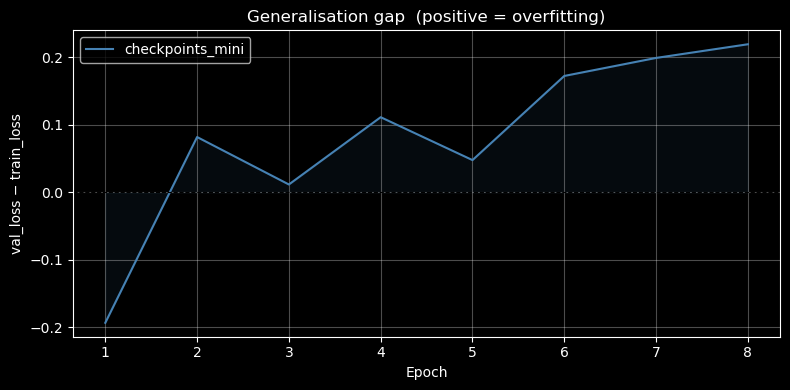

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, r in enumerate(runs):
    df    = r["df"]
    color = PALETTE[i % len(PALETTE)]
    gap   = df["val_loss"] - df["train_loss"]
    ax.plot(df["epoch"], gap, "-", color=color, label=r["label"])

ax.axhline(0, color="k", lw=0.8, ls="--")
ax.fill_between(runs[0]["df"]["epoch"],
                runs[0]["df"]["val_loss"] - runs[0]["df"]["train_loss"],
                0, alpha=0.08, color=PALETTE[0])
ax.set_xlabel("Epoch")
ax.set_ylabel("val_loss − train_loss")
ax.set_title("Generalisation gap  (positive = overfitting)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6 — Load checkpoint and inspect weights

In [9]:
import torch

# Choose which run to inspect
RUN_IDX   = 0       # index into LOG_DIRS
CKPT_NAME = "best.pt"   # or "last.pt" / "epoch_010.pt"

ckpt_path = os.path.join(LOG_DIRS[RUN_IDX], CKPT_NAME)
if not os.path.exists(ckpt_path):
    print(f"{ckpt_path} not found — list available checkpoints:")
    for fn in sorted(os.listdir(LOG_DIRS[RUN_IDX])):
        print(f"  {fn}")
else:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    print(f"Checkpoint: {ckpt_path}")
    print(f"  Saved at epoch : {ckpt.get('epoch', 'n/a')}")
    print(f"  val_loss       : {ckpt.get('val_loss', 'n/a')}")
    print(f"  train_loss     : {ckpt.get('train_loss', 'n/a')}")
    print(f"  Keys           : {list(ckpt.keys())}")
    print(f"\n  Weight tensors : {len(ckpt['model_state_dict'])}")
    total_params = sum(v.numel() for v in ckpt["model_state_dict"].values())
    print(f"  Total params   : {total_params:,}")

Checkpoint: ./checkpoints_mini/best.pt
  Saved at epoch : 5
  val_loss       : 0.643230065703392
  train_loss     : 0.5954125598073006
  Keys           : ['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'train_loss', 'val_loss', 'val_rmse', 'cfg']

  Weight tensors : 97
  Total params   : 143,869


## 7 — Gradient-norm proxy  (std of encoder weight deltas)

Compare `best.pt` weights to `last.pt` to see how much the model drifted
after the best epoch — a large drift with rising val loss signals overfitting.

In [10]:
run_dir = LOG_DIRS[RUN_IDX]
best_path = os.path.join(run_dir, "best.pt")
last_path = os.path.join(run_dir, "last.pt")

if not (os.path.exists(best_path) and os.path.exists(last_path)):
    print("best.pt or last.pt not found — skip this cell")
else:
    best_sd = torch.load(best_path, map_location="cpu")["model_state_dict"]
    last_sd = torch.load(last_path, map_location="cpu")["model_state_dict"]

    diffs = []
    for k in best_sd:
        if best_sd[k].dtype == torch.float32:
            d = (last_sd[k] - best_sd[k]).abs().mean().item()
            diffs.append((k, d))

    diffs.sort(key=lambda x: x[1], reverse=True)
    print("Top 10 most-changed weight tensors  (last.pt vs best.pt):")
    print(f"  {'Layer':<55}  mean |Δw|")
    print("  " + "-" * 68)
    for k, d in diffs[:10]:
        print(f"  {k:<55}  {d:.6f}")

    total_drift = sum(d for _, d in diffs) / len(diffs)
    print(f"\nMean weight drift across all layers: {total_drift:.6f}")

Top 10 most-changed weight tensors  (last.pt vs best.pt):
  Layer                                                    mean |Δw|
  --------------------------------------------------------------------
  encoder.var_proj.var_weights                             0.012393
  decoder.blocks.0.attn.in_proj_bias                       0.006741
  decoder.blocks.0.norm1.weight                            0.004833
  encoder.pos_emb.proj.2.weight                            0.004568
  encoder.station_emb.proj.2.weight                        0.004093
  decoder.blocks.0.norm1.bias                              0.003604
  decoder.blocks.0.attn.in_proj_weight                     0.003517
  encoder.temporal_emb.proj.2.weight                       0.003467
  decoder.pos_emb.proj.0.weight                            0.003387
  decoder.delta_emb.proj.2.weight                          0.003263

Mean weight drift across all layers: 0.001726


---
## Notes

- **`logs.csv` columns**: `epoch`, `train_loss`, `val_loss`, `val_rmse`, `epoch_secs`
- All loss values are in **normalised space** (mean≈0, std≈1 per variable)
- To convert val_rmse to physical units: multiply by `obs_stats['std'][v]`
- For multi-run comparisons add more paths to `LOG_DIRS`